#Silver Layer Script#

In [0]:
from pyspark.sql.functions import *
from pyspark.sql.types import *

###Data Access Using Key###

In [0]:
storage_account_name = "storagedatalakenazi"
storage_account_key = "<YOUR_STORAGE_ACCOUNT_KEY>"

spark.conf.set(
    f"fs.azure.account.key.{storage_account_name}.dfs.core.windows.net",
    storage_account_key
)

##Data Loading##

#### Read AdventureWorks_Calendar Data####

In [0]:
df_cal = spark.read.format("csv").option("header",True).option("inferSchema",True).load('abfss://bronze@storagedatalakenazi.dfs.core.windows.net/AdventureWorks_Calendar')



In [0]:
df_cal.limit(10).display()

Date
2015-01-01
2015-01-02
2015-01-03
2015-01-04
2015-01-05
2015-01-06
2015-01-07
2015-01-08
2015-01-09
2015-01-10


####Read AdventureWorks_Customers Data####

In [0]:
df_cus = spark.read.format("csv").option("header",True).option("inferSchema",True).load('abfss://bronze@storagedatalakenazi.dfs.core.windows.net/AdventureWorks_Customers')



In [0]:
df_cus.limit(10).display()

CustomerKey,Prefix,FirstName,LastName,BirthDate,MaritalStatus,Gender,EmailAddress,AnnualIncome,TotalChildren,EducationLevel,Occupation,HomeOwner
11000,MR.,JON,YANG,1966-04-08,M,M,jon24@adventure-works.com,"$90,000",2,Bachelors,Professional,Y
11001,MR.,EUGENE,HUANG,1965-05-14,S,M,eugene10@adventure-works.com,"$60,000",3,Bachelors,Professional,N
11002,MR.,RUBEN,TORRES,1965-08-12,M,M,ruben35@adventure-works.com,"$60,000",3,Bachelors,Professional,Y
11003,MS.,CHRISTY,ZHU,1968-02-15,S,F,christy12@adventure-works.com,"$70,000",0,Bachelors,Professional,N
11004,MRS.,ELIZABETH,JOHNSON,1968-08-08,S,F,elizabeth5@adventure-works.com,"$80,000",5,Bachelors,Professional,Y
11005,MR.,JULIO,RUIZ,1965-08-05,S,M,julio1@adventure-works.com,"$70,000",0,Bachelors,Professional,Y
11007,MR.,MARCO,MEHTA,1964-05-09,M,M,marco14@adventure-works.com,"$60,000",3,Bachelors,Professional,Y
11008,MRS.,ROBIN,VERHOFF,1964-07-07,S,F,rob4@adventure-works.com,"$60,000",4,Bachelors,Professional,Y
11009,MR.,SHANNON,CARLSON,1964-04-01,S,M,shannon38@adventure-works.com,"$70,000",0,Bachelors,Professional,N
11010,MS.,JACQUELYN,SUAREZ,1964-02-06,S,F,jacquelyn20@adventure-works.com,"$70,000",0,Bachelors,Professional,N


####Read AdventureWorks_Product_Categories Data####

In [0]:
df_cat = spark.read.format("csv").option("header",True).option("inferSchema",True).load('abfss://bronze@storagedatalakenazi.dfs.core.windows.net/AdventureWorks_Product_Categories')

In [0]:
df_cat.display()   

ProductCategoryKey,CategoryName
1,Bikes
2,Components
3,Clothing
4,Accessories


####Read AdventureWorks_Product_Subcategories Data####

In [0]:
df_subcat = spark.read.format("csv").option("header",True).option("inferSchema",True).load('abfss://bronze@storagedatalakenazi.dfs.core.windows.net/AdventureWorks_Product_Subcategories')

In [0]:
df_subcat.limit(10).display()

ProductSubcategoryKey,SubcategoryName,ProductCategoryKey
1,Mountain Bikes,1
2,Road Bikes,1
3,Touring Bikes,1
4,Handlebars,2
5,Bottom Brackets,2
6,Brakes,2
7,Chains,2
8,Cranksets,2
9,Derailleurs,2
10,Forks,2


####AdventureWorks_Products####

In [0]:
df_prod = spark.read.format("csv").option("header",True).option("inferSchema",True).load('abfss://bronze@storagedatalakenazi.dfs.core.windows.net/AdventureWorks_Products')

In [0]:
df_prod.limit(10).display()

ProductKey,ProductSubcategoryKey,ProductSKU,ProductName,ModelName,ProductDescription,ProductColor,ProductSize,ProductStyle,ProductCost,ProductPrice
214,31,HL-U509-R,"Sport-100 Helmet, Red",Sport-100,"Universal fit, well-vented, lightweight , snap-on visor.",Red,0,0,13.0863,34.99
215,31,HL-U509,"Sport-100 Helmet, Black",Sport-100,"Universal fit, well-vented, lightweight , snap-on visor.",Black,0,0,12.0278,33.6442
218,23,SO-B909-M,"Mountain Bike Socks, M",Mountain Bike Socks,Combination of natural and synthetic fibers stays dry and provides just the right cushioning.,White,M,U,3.3963,9.5
219,23,SO-B909-L,"Mountain Bike Socks, L",Mountain Bike Socks,Combination of natural and synthetic fibers stays dry and provides just the right cushioning.,White,L,U,3.3963,9.5
220,31,HL-U509-B,"Sport-100 Helmet, Blue",Sport-100,"Universal fit, well-vented, lightweight , snap-on visor.",Blue,0,0,12.0278,33.6442
223,19,CA-1098,AWC Logo Cap,Cycling Cap,Traditional style with a flip-up brim; one-size fits all.,Multi,0,U,5.7052,8.6442
226,21,LJ-0192-S,"Long-Sleeve Logo Jersey, S",Long-Sleeve Logo Jersey,Unisex long-sleeve AWC logo microfiber cycling jersey,Multi,S,U,31.7244,48.0673
229,21,LJ-0192-M,"Long-Sleeve Logo Jersey, M",Long-Sleeve Logo Jersey,Unisex long-sleeve AWC logo microfiber cycling jersey,Multi,M,U,31.7244,48.0673
232,21,LJ-0192-L,"Long-Sleeve Logo Jersey, L",Long-Sleeve Logo Jersey,Unisex long-sleeve AWC logo microfiber cycling jersey,Multi,L,U,31.7244,48.0673
235,21,LJ-0192-X,"Long-Sleeve Logo Jersey, XL",Long-Sleeve Logo Jersey,Unisex long-sleeve AWC logo microfiber cycling jersey,Multi,XL,U,31.7244,48.0673


####AdventureWorks_Returns####

In [0]:
df_return = spark.read.format("csv").option("header",True).option("inferSchema",True).load('abfss://bronze@storagedatalakenazi.dfs.core.windows.net/AdventureWorks_Returns')

In [0]:
df_return.limit(10).display()

ReturnDate,TerritoryKey,ProductKey,ReturnQuantity
2015-01-18,9,312,1
2015-01-18,10,310,1
2015-01-21,8,346,1
2015-01-22,4,311,1
2015-02-02,6,312,1
2015-02-15,1,312,1
2015-02-19,9,311,1
2015-02-24,8,314,1
2015-03-08,8,350,1
2015-03-13,9,350,1


####AdventureWorks_Sales_2015####

In [0]:
df_sales = spark.read.format("csv").option("header",True).option("inferSchema",True).load('abfss://bronze@storagedatalakenazi.dfs.core.windows.net/AdventureWorks_Sales_2015')

In [0]:
df_sales.limit(10).display()

OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity
2015-01-01,2001-09-21,SO45080,332,14657,1,1,1
2015-01-01,2001-12-05,SO45079,312,29255,4,1,1
2015-01-01,2001-10-29,SO45082,350,11455,9,1,1
2015-01-01,2001-11-16,SO45081,338,26782,6,1,1
2015-01-02,2001-12-15,SO45083,312,14947,10,1,1
2015-01-02,2001-10-12,SO45084,310,29143,4,1,1
2015-01-02,2001-12-18,SO45086,314,18747,9,1,1
2015-01-02,2001-10-09,SO45085,312,18746,9,1,1
2015-01-03,2001-10-03,SO45093,312,18906,9,1,1
2015-01-03,2001-09-29,SO45090,310,29170,4,1,1


####AdventureWorks_Sales_2016####

In [0]:
df_sales16 = spark.read.format("csv").option("header",True).option("inferSchema",True).load('abfss://bronze@storagedatalakenazi.dfs.core.windows.net/AdventureWorks_Sales_2016')

In [0]:
df_sales16.limit(10).display()

OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity
2016-01-01,2002-10-17,SO48797,385,14335,1,1,1
2016-01-01,2002-09-30,SO48802,383,24923,9,1,1
2016-01-01,2002-11-29,SO48801,326,15493,1,1,1
2016-01-01,2002-11-16,SO48799,352,26708,4,1,1
2016-01-01,2002-12-16,SO48798,369,23332,9,1,1
2016-01-01,2002-12-02,SO48800,342,15491,5,1,1
2016-01-01,2002-10-19,SO48795,375,16538,8,1,1
2016-01-01,2002-11-23,SO48796,375,15094,7,1,1
2016-01-02,2002-12-01,SO48804,356,12276,8,1,1
2016-01-02,2002-09-12,SO48814,360,13647,9,1,1


####AdventureWorks_Sales_2017####

In [0]:
df_sales17 = spark.read.format("csv").option("header",True).option("inferSchema",True).load('abfss://bronze@storagedatalakenazi.dfs.core.windows.net/AdventureWorks_Sales_2017')

In [0]:
df_sales17.limit(10).display()

OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity
2017-01-01,2003-12-13,SO61285,529,23791,1,2,2
2017-01-01,2003-09-24,SO61285,214,23791,1,3,1
2017-01-01,2003-09-04,SO61285,540,23791,1,1,1
2017-01-01,2003-09-28,SO61301,529,16747,1,2,2
2017-01-01,2003-10-21,SO61301,377,16747,1,1,1
2017-01-01,2003-10-23,SO61301,540,16747,1,3,1
2017-01-01,2003-09-04,SO61269,215,11792,4,1,1
2017-01-01,2003-10-21,SO61269,229,11792,4,2,1
2017-01-01,2003-10-24,SO61286,528,11530,6,2,2
2017-01-01,2003-09-27,SO61286,536,11530,6,1,2


####Sales####

In [0]:
df_sales = spark.read.format("csv").option("header",True).option("inferSchema",True).load('abfss://bronze@storagedatalakenazi.dfs.core.windows.net/AdventureWorks_Sales*')

In [0]:
df_sales.limit(10).display()

OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity
2017-01-01,2003-12-13,SO61285,529,23791,1,2,2
2017-01-01,2003-09-24,SO61285,214,23791,1,3,1
2017-01-01,2003-09-04,SO61285,540,23791,1,1,1
2017-01-01,2003-09-28,SO61301,529,16747,1,2,2
2017-01-01,2003-10-21,SO61301,377,16747,1,1,1
2017-01-01,2003-10-23,SO61301,540,16747,1,3,1
2017-01-01,2003-09-04,SO61269,215,11792,4,1,1
2017-01-01,2003-10-21,SO61269,229,11792,4,2,1
2017-01-01,2003-10-24,SO61286,528,11530,6,2,2
2017-01-01,2003-09-27,SO61286,536,11530,6,1,2


####AdventureWorks_Territories####

In [0]:
df_terr = spark.read.format("csv").option("header",True).option("inferSchema",True).load('abfss://bronze@storagedatalakenazi.dfs.core.windows.net/AdventureWorks_Territories')

In [0]:
df_terr.display()

SalesTerritoryKey,Region,Country,Continent
1,Northwest,United States,North America
2,Northeast,United States,North America
3,Central,United States,North America
4,Southwest,United States,North America
5,Southeast,United States,North America
6,Canada,Canada,North America
7,France,France,Europe
8,Germany,Germany,Europe
9,Australia,Australia,Pacific
10,United Kingdom,United Kingdom,Europe


####products####

In [0]:
df_products = spark.read.format("csv").option("header",True).option("inferSchema",True).load('abfss://bronze@storagedatalakenazi.dfs.core.windows.net/products')

In [0]:
df_products.limit(10).display()

ProductKey,ProductSubcategoryKey,ProductSKU,ProductName,ModelName,ProductDescription,ProductColor,ProductSize,ProductStyle,ProductCost,ProductPrice
214,31,HL-U509-R,"Sport-100 Helmet, Red",Sport-100,"Universal fit, well-vented, lightweight , snap-on visor.",Red,0,0,13.0863,34.99
215,31,HL-U509,"Sport-100 Helmet, Black",Sport-100,"Universal fit, well-vented, lightweight , snap-on visor.",Black,0,0,12.0278,33.6442
218,23,SO-B909-M,"Mountain Bike Socks, M",Mountain Bike Socks,Combination of natural and synthetic fibers stays dry and provides just the right cushioning.,White,M,U,3.3963,9.5
219,23,SO-B909-L,"Mountain Bike Socks, L",Mountain Bike Socks,Combination of natural and synthetic fibers stays dry and provides just the right cushioning.,White,L,U,3.3963,9.5
220,31,HL-U509-B,"Sport-100 Helmet, Blue",Sport-100,"Universal fit, well-vented, lightweight , snap-on visor.",Blue,0,0,12.0278,33.6442
223,19,CA-1098,AWC Logo Cap,Cycling Cap,Traditional style with a flip-up brim; one-size fits all.,Multi,0,U,5.7052,8.6442
226,21,LJ-0192-S,"Long-Sleeve Logo Jersey, S",Long-Sleeve Logo Jersey,Unisex long-sleeve AWC logo microfiber cycling jersey,Multi,S,U,31.7244,48.0673
229,21,LJ-0192-M,"Long-Sleeve Logo Jersey, M",Long-Sleeve Logo Jersey,Unisex long-sleeve AWC logo microfiber cycling jersey,Multi,M,U,31.7244,48.0673
232,21,LJ-0192-L,"Long-Sleeve Logo Jersey, L",Long-Sleeve Logo Jersey,Unisex long-sleeve AWC logo microfiber cycling jersey,Multi,L,U,31.7244,48.0673
235,21,LJ-0192-X,"Long-Sleeve Logo Jersey, XL",Long-Sleeve Logo Jersey,Unisex long-sleeve AWC logo microfiber cycling jersey,Multi,XL,U,31.7244,48.0673


#Transformations#

####AdventureWorks_Calendar Transformation####

In [0]:
df_cal = df_cal.withColumn('Month', month(col('Date'))).withColumn('Year', year(col('Date')))
df_cal.limit(10).display()

Date,Month,Year
2015-01-01,1,2015
2015-01-02,1,2015
2015-01-03,1,2015
2015-01-04,1,2015
2015-01-05,1,2015
2015-01-06,1,2015
2015-01-07,1,2015
2015-01-08,1,2015
2015-01-09,1,2015
2015-01-10,1,2015


In [0]:
df_cal.write.format('parquet').mode('append').option("path","abfss://silver@storagedatalakenazi.dfs.core.windows.net/AdventureWorks_Calendar").save()

####Customer Transformation####

In [0]:
df_cus.limit(10).display()

CustomerKey,Prefix,FirstName,LastName,BirthDate,MaritalStatus,Gender,EmailAddress,AnnualIncome,TotalChildren,EducationLevel,Occupation,HomeOwner
11000,MR.,JON,YANG,1966-04-08,M,M,jon24@adventure-works.com,"$90,000",2,Bachelors,Professional,Y
11001,MR.,EUGENE,HUANG,1965-05-14,S,M,eugene10@adventure-works.com,"$60,000",3,Bachelors,Professional,N
11002,MR.,RUBEN,TORRES,1965-08-12,M,M,ruben35@adventure-works.com,"$60,000",3,Bachelors,Professional,Y
11003,MS.,CHRISTY,ZHU,1968-02-15,S,F,christy12@adventure-works.com,"$70,000",0,Bachelors,Professional,N
11004,MRS.,ELIZABETH,JOHNSON,1968-08-08,S,F,elizabeth5@adventure-works.com,"$80,000",5,Bachelors,Professional,Y
11005,MR.,JULIO,RUIZ,1965-08-05,S,M,julio1@adventure-works.com,"$70,000",0,Bachelors,Professional,Y
11007,MR.,MARCO,MEHTA,1964-05-09,M,M,marco14@adventure-works.com,"$60,000",3,Bachelors,Professional,Y
11008,MRS.,ROBIN,VERHOFF,1964-07-07,S,F,rob4@adventure-works.com,"$60,000",4,Bachelors,Professional,Y
11009,MR.,SHANNON,CARLSON,1964-04-01,S,M,shannon38@adventure-works.com,"$70,000",0,Bachelors,Professional,N
11010,MS.,JACQUELYN,SUAREZ,1964-02-06,S,F,jacquelyn20@adventure-works.com,"$70,000",0,Bachelors,Professional,N


In [0]:
df_cus.withColumn('Full_Name', concat(col('prefix'),lit(' '),col('firstname'), lit(' '), col('lastname'))).limit(10).display()

CustomerKey,Prefix,FirstName,LastName,BirthDate,MaritalStatus,Gender,EmailAddress,AnnualIncome,TotalChildren,EducationLevel,Occupation,HomeOwner,Full_Name
11000,MR.,JON,YANG,1966-04-08,M,M,jon24@adventure-works.com,"$90,000",2,Bachelors,Professional,Y,MR. JON YANG
11001,MR.,EUGENE,HUANG,1965-05-14,S,M,eugene10@adventure-works.com,"$60,000",3,Bachelors,Professional,N,MR. EUGENE HUANG
11002,MR.,RUBEN,TORRES,1965-08-12,M,M,ruben35@adventure-works.com,"$60,000",3,Bachelors,Professional,Y,MR. RUBEN TORRES
11003,MS.,CHRISTY,ZHU,1968-02-15,S,F,christy12@adventure-works.com,"$70,000",0,Bachelors,Professional,N,MS. CHRISTY ZHU
11004,MRS.,ELIZABETH,JOHNSON,1968-08-08,S,F,elizabeth5@adventure-works.com,"$80,000",5,Bachelors,Professional,Y,MRS. ELIZABETH JOHNSON
11005,MR.,JULIO,RUIZ,1965-08-05,S,M,julio1@adventure-works.com,"$70,000",0,Bachelors,Professional,Y,MR. JULIO RUIZ
11007,MR.,MARCO,MEHTA,1964-05-09,M,M,marco14@adventure-works.com,"$60,000",3,Bachelors,Professional,Y,MR. MARCO MEHTA
11008,MRS.,ROBIN,VERHOFF,1964-07-07,S,F,rob4@adventure-works.com,"$60,000",4,Bachelors,Professional,Y,MRS. ROBIN VERHOFF
11009,MR.,SHANNON,CARLSON,1964-04-01,S,M,shannon38@adventure-works.com,"$70,000",0,Bachelors,Professional,N,MR. SHANNON CARLSON
11010,MS.,JACQUELYN,SUAREZ,1964-02-06,S,F,jacquelyn20@adventure-works.com,"$70,000",0,Bachelors,Professional,N,MS. JACQUELYN SUAREZ


In [0]:
df_cus = df_cus.withColumn('Full_Name', concat_ws(' ', col('prefix'), col('FirstName'), col('LastName')))

In [0]:
df_cus.limit(10).display()


CustomerKey,Prefix,FirstName,LastName,BirthDate,MaritalStatus,Gender,EmailAddress,AnnualIncome,TotalChildren,EducationLevel,Occupation,HomeOwner,Full_Name
11000,MR.,JON,YANG,1966-04-08,M,M,jon24@adventure-works.com,"$90,000",2,Bachelors,Professional,Y,MR. JON YANG
11001,MR.,EUGENE,HUANG,1965-05-14,S,M,eugene10@adventure-works.com,"$60,000",3,Bachelors,Professional,N,MR. EUGENE HUANG
11002,MR.,RUBEN,TORRES,1965-08-12,M,M,ruben35@adventure-works.com,"$60,000",3,Bachelors,Professional,Y,MR. RUBEN TORRES
11003,MS.,CHRISTY,ZHU,1968-02-15,S,F,christy12@adventure-works.com,"$70,000",0,Bachelors,Professional,N,MS. CHRISTY ZHU
11004,MRS.,ELIZABETH,JOHNSON,1968-08-08,S,F,elizabeth5@adventure-works.com,"$80,000",5,Bachelors,Professional,Y,MRS. ELIZABETH JOHNSON
11005,MR.,JULIO,RUIZ,1965-08-05,S,M,julio1@adventure-works.com,"$70,000",0,Bachelors,Professional,Y,MR. JULIO RUIZ
11007,MR.,MARCO,MEHTA,1964-05-09,M,M,marco14@adventure-works.com,"$60,000",3,Bachelors,Professional,Y,MR. MARCO MEHTA
11008,MRS.,ROBIN,VERHOFF,1964-07-07,S,F,rob4@adventure-works.com,"$60,000",4,Bachelors,Professional,Y,MRS. ROBIN VERHOFF
11009,MR.,SHANNON,CARLSON,1964-04-01,S,M,shannon38@adventure-works.com,"$70,000",0,Bachelors,Professional,N,MR. SHANNON CARLSON
11010,MS.,JACQUELYN,SUAREZ,1964-02-06,S,F,jacquelyn20@adventure-works.com,"$70,000",0,Bachelors,Professional,N,MS. JACQUELYN SUAREZ


In [0]:
df_cus.write.format('parquet').mode('append').option("path","abfss://silver@storagedatalakenazi.dfs.core.windows.net/AdventureWorks_Customers").save()

####Product_Subcategories Transformations####

In [0]:
df_subcat.write.format('parquet').mode('append').option("path","abfss://silver@storagedatalakenazi.dfs.core.windows.net/AdventureWorks_Product_Subcategories").save()

####Products Transformation####

In [0]:
df_products = df_products.withColumn('ProductSKU', split(col('ProductSKU'), '-')[0]).withColumn('ProductName', split(col('ProductName'), ' ')[0])

In [0]:
df_products.limit(10).display()

ProductKey,ProductSubcategoryKey,ProductSKU,ProductName,ModelName,ProductDescription,ProductColor,ProductSize,ProductStyle,ProductCost,ProductPrice
214,31,HL,Sport-100,Sport-100,"Universal fit, well-vented, lightweight , snap-on visor.",Red,0,0,13.0863,34.99
215,31,HL,Sport-100,Sport-100,"Universal fit, well-vented, lightweight , snap-on visor.",Black,0,0,12.0278,33.6442
218,23,SO,Mountain,Mountain Bike Socks,Combination of natural and synthetic fibers stays dry and provides just the right cushioning.,White,M,U,3.3963,9.5
219,23,SO,Mountain,Mountain Bike Socks,Combination of natural and synthetic fibers stays dry and provides just the right cushioning.,White,L,U,3.3963,9.5
220,31,HL,Sport-100,Sport-100,"Universal fit, well-vented, lightweight , snap-on visor.",Blue,0,0,12.0278,33.6442
223,19,CA,AWC,Cycling Cap,Traditional style with a flip-up brim; one-size fits all.,Multi,0,U,5.7052,8.6442
226,21,LJ,Long-Sleeve,Long-Sleeve Logo Jersey,Unisex long-sleeve AWC logo microfiber cycling jersey,Multi,S,U,31.7244,48.0673
229,21,LJ,Long-Sleeve,Long-Sleeve Logo Jersey,Unisex long-sleeve AWC logo microfiber cycling jersey,Multi,M,U,31.7244,48.0673
232,21,LJ,Long-Sleeve,Long-Sleeve Logo Jersey,Unisex long-sleeve AWC logo microfiber cycling jersey,Multi,L,U,31.7244,48.0673
235,21,LJ,Long-Sleeve,Long-Sleeve Logo Jersey,Unisex long-sleeve AWC logo microfiber cycling jersey,Multi,XL,U,31.7244,48.0673


In [0]:
df_products.write.format('parquet').mode('append').option("path","abfss://silver@storagedatalakenazi.dfs.core.windows.net/AdventureWorks_Products").save()

####AdventureWorks_Returns Transformation####

In [0]:
df_return.write.format('parquet').mode('append').option("path","abfss://silver@storagedatalakenazi.dfs.core.windows.net/AdventureWorks_Returns").save()

####AdventureWorks_Territories Transformation####

In [0]:
df_terr.write.format('parquet').mode('append').option("path","abfss://silver@storagedatalakenazi.dfs.core.windows.net/AdventureWorks_Territories").save()

####Sales Transformation####

In [0]:
df_sales.limit(10).display()

OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity
2017-01-01,2003-12-13,SO61285,529,23791,1,2,2
2017-01-01,2003-09-24,SO61285,214,23791,1,3,1
2017-01-01,2003-09-04,SO61285,540,23791,1,1,1
2017-01-01,2003-09-28,SO61301,529,16747,1,2,2
2017-01-01,2003-10-21,SO61301,377,16747,1,1,1
2017-01-01,2003-10-23,SO61301,540,16747,1,3,1
2017-01-01,2003-09-04,SO61269,215,11792,4,1,1
2017-01-01,2003-10-21,SO61269,229,11792,4,2,1
2017-01-01,2003-10-24,SO61286,528,11530,6,2,2
2017-01-01,2003-09-27,SO61286,536,11530,6,1,2


In [0]:
df_sales = df_sales.withColumn('StockDate', to_timestamp(col('StockDate')))

In [0]:
df_sales = df_sales.withColumn('ordernumber', regexp_replace('ordernumber', 'S', 'T'))

In [0]:
df_sales = df_sales.withColumn('multiply', col('OrderLineItem') * col('OrderQuantity'))

In [0]:
df_sales.limit(10).display()

OrderDate,StockDate,ordernumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity,multiply
2017-01-01,2003-12-13T00:00:00Z,TO61285,529,23791,1,2,2,4
2017-01-01,2003-09-24T00:00:00Z,TO61285,214,23791,1,3,1,3
2017-01-01,2003-09-04T00:00:00Z,TO61285,540,23791,1,1,1,1
2017-01-01,2003-09-28T00:00:00Z,TO61301,529,16747,1,2,2,4
2017-01-01,2003-10-21T00:00:00Z,TO61301,377,16747,1,1,1,1
2017-01-01,2003-10-23T00:00:00Z,TO61301,540,16747,1,3,1,3
2017-01-01,2003-09-04T00:00:00Z,TO61269,215,11792,4,1,1,1
2017-01-01,2003-10-21T00:00:00Z,TO61269,229,11792,4,2,1,2
2017-01-01,2003-10-24T00:00:00Z,TO61286,528,11530,6,2,2,4
2017-01-01,2003-09-27T00:00:00Z,TO61286,536,11530,6,1,2,2


##Sales Analysis##

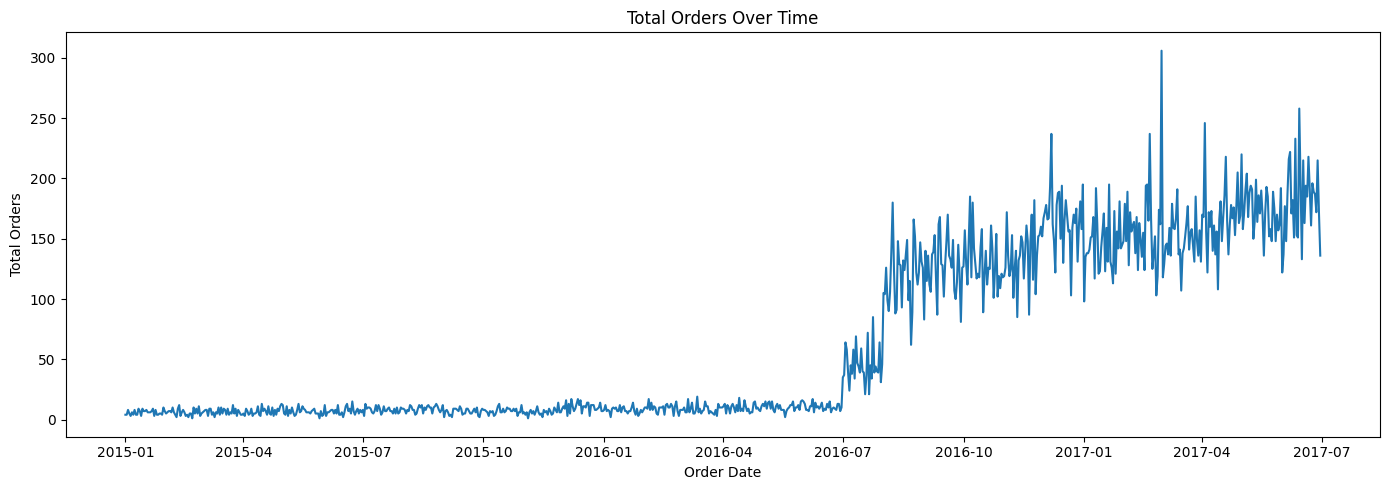

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

orders_by_date = df_sales.groupBy('OrderDate').agg(count('ordernumber').alias('Total_Orders')).toPandas()
orders_by_date = orders_by_date.sort_values('OrderDate')

plt.figure(figsize=(14, 5))
plt.plot(orders_by_date['OrderDate'], orders_by_date['Total_Orders'])
plt.xlabel('Order Date')
plt.ylabel('Total Orders')
plt.title('Total Orders Over Time')
plt.tight_layout()
plt.show()

In [0]:
products_by_cat = df_prod.join(df_subcat, df_prod.ProductSubcategoryKey == df_subcat.ProductSubcategoryKey) \
    .join(df_cat, df_subcat.ProductCategoryKey == df_cat.ProductCategoryKey) \
    .groupBy("CategoryName").count().toPandas()

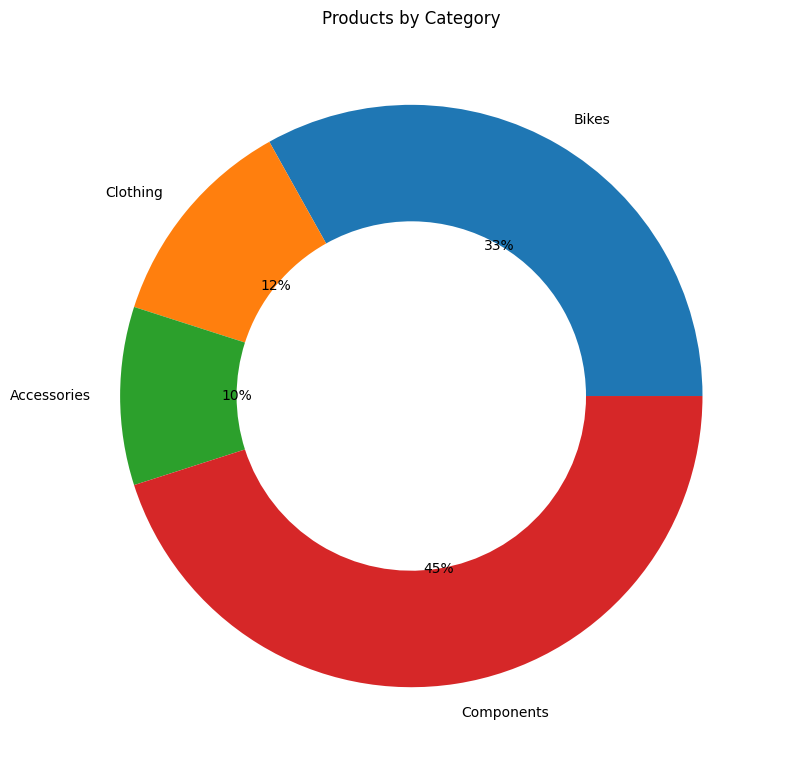

In [0]:
plt.figure(figsize=(8, 8))
plt.pie(
    products_by_cat["count"],
    labels=products_by_cat["CategoryName"],
    autopct='%1.0f%%',
    wedgeprops=dict(width=0.4)  # this creates the donut hole
)
plt.title("Products by Category")
plt.tight_layout()
plt.show()

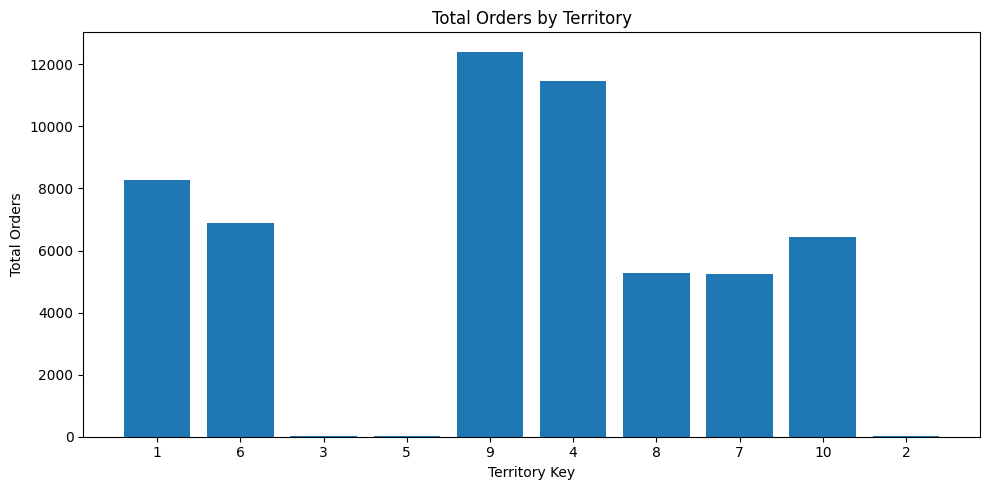

In [0]:

sales_by_terr = df_sales.groupBy("TerritoryKey").agg(count("OrderNumber").alias("Total_Orders")).toPandas()

plt.figure(figsize=(10, 5))
plt.bar(sales_by_terr["TerritoryKey"].astype(str), sales_by_terr["Total_Orders"])
plt.xlabel("Territory Key")
plt.ylabel("Total Orders")
plt.title("Total Orders by Territory")
plt.tight_layout()
plt.show()

In [0]:
df_sales.write.format('parquet').mode('append').option("path","abfss://silver@storagedatalakenazi.dfs.core.windows.net/AdventureWorks_Sales").save()